# 📓 Notebook 07 – Improved ANN + PSO
## Lettuce Fresh Weight Prediction | Enhanced Pipeline

**Tujuan:** Meningkatkan performa dari baseline tanpa data tambahan.

### Strategi Perbaikan:
| # | Strategi | Alasan |
|---|----------|--------|
| 1 | **Feature Selection** | 17 fitur + 80 sampel = overfitting; kurangi ke fitur paling informatif |
| 2 | **Log Transform target y** | Jika distribusi berat skewed, log-transform stabilkan variance |
| 3 | **StandardScaler** | Lebih robust terhadap outlier dibanding MinMaxScaler |
| 4 | **PSO diperluas** | Cari layer 1–3, neuron lebih lebar, alpha lebih besar |
| 5 | **Regularisasi lebih kuat** | Alpha besar mencegah overfitting pada dataset kecil |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, joblib, time, warnings
warnings.filterwarnings('ignore')

import pyswarms as ps
from pyswarms.single import GlobalBestPSO

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from scipy.stats import shapiro, skew

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460', 'axes.grid': True,
})
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
BASE_DIR = r'D:/laragon/www/lettuce-weight-prediction'

df = pd.read_csv(f'{BASE_DIR}/data/dataset.csv')

ALL_FEATURES = [
    'leaf_area', 'perimeter', 'aspect_ratio', 'extent', 'equivalent_diameter',
    'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'std_G',
    'contrast', 'energy', 'homogeneity', 'correlation', 'entropy'
]

X_all = df[ALL_FEATURES].values
y     = df['weight_gram'].values

print(f'✅ Dataset: {len(df)} sampel | {len(ALL_FEATURES)} fitur')
print(f'   Berat  : {y.min():.1f}g – {y.max():.1f}g')
print(f'   Rata2  : {y.mean():.2f}g | Std: {y.std():.2f}g')
print(f'   Skewness: {skew(y):.4f}')

✅ Dataset: 200 sampel | 17 fitur
   Berat  : 18.0g – 45.0g
   Rata2  : 31.97g | Std: 5.87g
   Skewness: 0.1731


---
## 🔢 STEP 1 – Analisis Distribusi & Log Transform

📊 UJI DISTRIBUSI TARGET (Berat Selada):
   Shapiro-Wilk: W=0.9807, p=0.0076
   Skewness    : 0.1731
   → Log Transform: ❌ Tidak perlu (distribusi cukup normal)


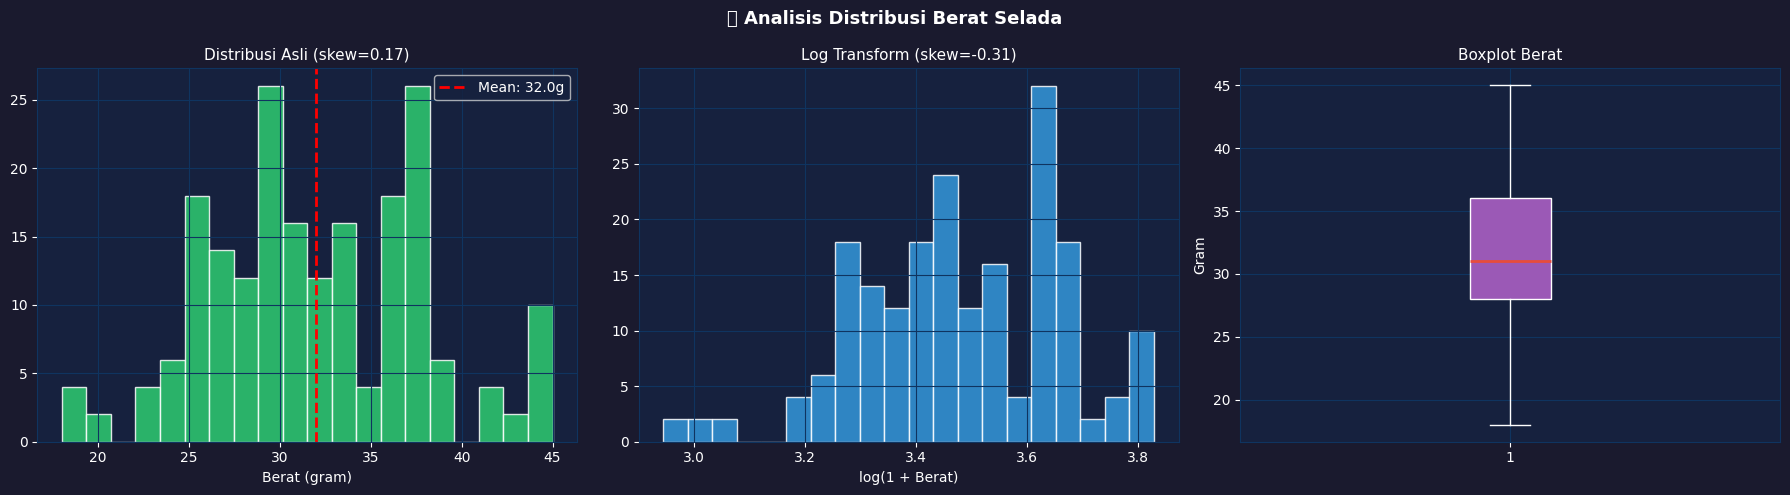


✅ Menggunakan y asli sebagai target


In [3]:
# Uji normalitas Shapiro-Wilk
stat, p_val = shapiro(y)
sk_val = skew(y)

print('📊 UJI DISTRIBUSI TARGET (Berat Selada):')
print(f'   Shapiro-Wilk: W={stat:.4f}, p={p_val:.4f}')
print(f'   Skewness    : {sk_val:.4f}')

USE_LOG = abs(sk_val) > 0.5  # Apply log transform jika skewness > 0.5
print(f'   → Log Transform: {"✅ AKTIF" if USE_LOG else "❌ Tidak perlu (distribusi cukup normal)"}')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Analisis Distribusi Berat Selada', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=20, color='#2ECC71', edgecolor='white', alpha=0.85)
axes[0].axvline(y.mean(), color='red', ls='--', lw=2, label=f'Mean: {y.mean():.1f}g')
axes[0].set_title(f'Distribusi Asli (skew={sk_val:.2f})', fontsize=11)
axes[0].set_xlabel('Berat (gram)'); axes[0].legend()

y_log = np.log1p(y)
axes[1].hist(y_log, bins=20, color='#3498DB', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Log Transform (skew={skew(y_log):.2f})', fontsize=11)
axes[1].set_xlabel('log(1 + Berat)')

axes[2].boxplot(y, patch_artist=True,
                 boxprops=dict(facecolor='#9B59B6', color='white'),
                 medianprops=dict(color='#E74C3C', lw=2),
                 whiskerprops=dict(color='white'), capprops=dict(color='white'),
                 flierprops=dict(marker='o', color='#E74C3C', alpha=0.6))
axes[2].set_title('Boxplot Berat', fontsize=11)
axes[2].set_ylabel('Gram')

plt.tight_layout()
os.makedirs(f'{BASE_DIR}/output/plots', exist_ok=True)
plt.savefig(f'{BASE_DIR}/output/plots/improved_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

# Set target
if USE_LOG:
    y_model = y_log
    print('\n✅ Menggunakan log(1+y) sebagai target')
else:
    y_model = y
    print('\n✅ Menggunakan y asli sebagai target')

---
## 🔍 STEP 2 – Feature Selection (Pilih K Fitur Terbaik)

📊 KORELASI FITUR DENGAN BERAT (|r|):
   1. equivalent_diameter      : 0.7410 |██████████████████████ ✅
   2. leaf_area                : 0.7408 |██████████████████████ ✅
   3. perimeter                : 0.5872 |█████████████████ ✅
   4. mean_S                   : 0.5854 |█████████████████ ✅
   5. homogeneity              : 0.4465 |█████████████ ✅
   6. mean_H                   : 0.4071 |████████████ ✅
   7. mean_G                   : 0.3214 |█████████ ✅
   8. energy                   : 0.3138 |█████████ ✅
   9. extent                   : 0.3115 |█████████ ✅
  10. mean_V                   : 0.3078 |█████████ ✅
  11. contrast                 : 0.2489 |███████ ⚠️
  12. mean_B                   : 0.2039 |██████ ⚠️
  13. mean_R                   : 0.1735 |█████ ⚠️
  14. aspect_ratio             : 0.1533 |████ ⚠️
  15. entropy                  : 0.1119 |███ ❌
  16. std_G                    : 0.0631 |█ ❌
  17. correlation              : 0.0329 | ❌


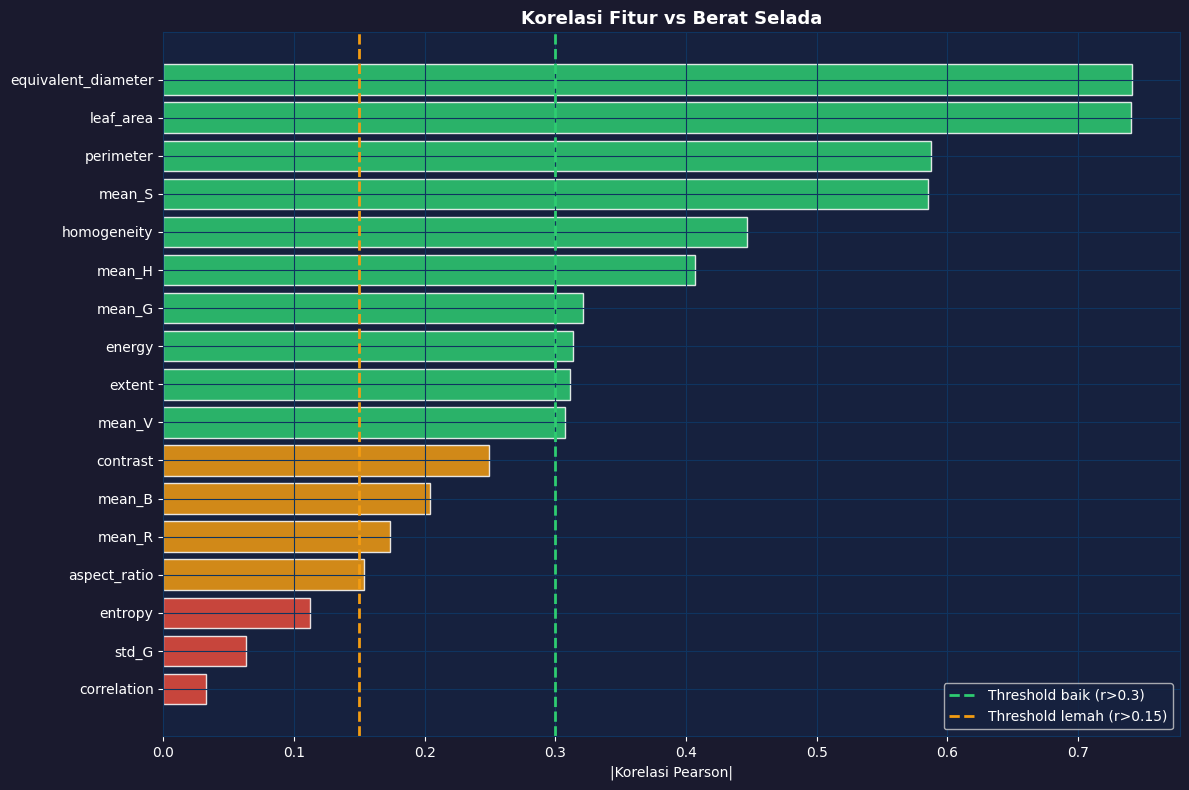


✅ Dipilih 10 fitur terbaik:
    1. equivalent_diameter
    2. leaf_area
    3. perimeter
    4. mean_S
    5. homogeneity
    6. mean_H
    7. mean_G
    8. energy
    9. extent
   10. mean_V


In [4]:
# Hitung korelasi setiap fitur dengan target
corr_with_y = [abs(np.corrcoef(df[f].values, y)[0,1]) for f in ALL_FEATURES]
corr_df = pd.DataFrame({'fitur': ALL_FEATURES, 'korelasi': corr_with_y})
corr_df = corr_df.sort_values('korelasi', ascending=False).reset_index(drop=True)

print('📊 KORELASI FITUR DENGAN BERAT (|r|):')
for i, row in corr_df.iterrows():
    bar   = '█' * int(row['korelasi'] * 30)
    label = '✅' if row['korelasi'] > 0.3 else ('⚠️' if row['korelasi'] > 0.15 else '❌')
    print(f'  {i+1:2d}. {row["fitur"]:25s}: {row["korelasi"]:.4f} |{bar} {label}')

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ECC71' if c > 0.3 else '#F39C12' if c > 0.15 else '#E74C3C' 
          for c in corr_df['korelasi']]
ax.barh(corr_df['fitur'][::-1], corr_df['korelasi'][::-1], 
         color=colors[::-1], edgecolor='white', alpha=0.85)
ax.axvline(0.3, color='#2ECC71', ls='--', lw=2, label='Threshold baik (r>0.3)')
ax.axvline(0.15, color='#F39C12', ls='--', lw=2, label='Threshold lemah (r>0.15)')
ax.set_title('Korelasi Fitur vs Berat Selada', fontsize=13, fontweight='bold')
ax.set_xlabel('|Korelasi Pearson|')
ax.legend()
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/improved_feature_correlation.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

# Pilih K fitur terbaik
K_FEATURES = 10  # Bisa dicoba: 8, 10, 12
SELECTED_FEATURES = corr_df['fitur'].head(K_FEATURES).tolist()

print(f'\n✅ Dipilih {K_FEATURES} fitur terbaik:')
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f'   {i:2d}. {f}')

---
## ⚙️ STEP 3 – Data Split & Scaler Comparison

In [5]:
X_sel = df[SELECTED_FEATURES].values

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y_model, test_size=0.2, random_state=42
)

# Bandingkan MinMaxScaler vs StandardScaler via CV cepat
def quick_cv(X_tr, y_tr, scaler_cls, label):
    kf    = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for tr, vl in kf.split(X_tr):
        sc  = scaler_cls()
        Xtr = sc.fit_transform(X_tr[tr])
        Xvl = sc.transform(X_tr[vl])
        m   = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                            solver='adam', alpha=0.01, max_iter=300, random_state=42)
        m.fit(Xtr, y_tr[tr])
        rmses.append(np.sqrt(mean_squared_error(y_tr[vl], m.predict(Xvl))))
    print(f'   {label:20s}: RMSE = {np.mean(rmses):.4f} ± {np.std(rmses):.4f}')
    return np.mean(rmses)

print('🔬 Perbandingan Scaler (5-Fold CV, ANN sederhana):')
rmse_mm = quick_cv(X_train, y_train, MinMaxScaler,  'MinMaxScaler')
rmse_ss = quick_cv(X_train, y_train, StandardScaler,'StandardScaler')

# Pilih scaler terbaik
if rmse_ss < rmse_mm:
    ScalerClass = StandardScaler
    scaler_name = 'StandardScaler'
else:
    ScalerClass = MinMaxScaler
    scaler_name = 'MinMaxScaler'

print(f'\n✅ Scaler terpilih: {scaler_name}')

scaler    = ScalerClass()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'   Training : {len(X_train)} sampel | Testing: {len(X_test)} sampel')

🔬 Perbandingan Scaler (5-Fold CV, ANN sederhana):
   MinMaxScaler        : RMSE = 4.2965 ± 0.5343
   StandardScaler      : RMSE = 8.4592 ± 1.3480

✅ Scaler terpilih: MinMaxScaler
   Training : 160 sampel | Testing: 40 sampel


---
## 🐝 STEP 4 – PSO Diperluas (5 Dimensi)

In [6]:
# ============================================================
# PSO diperluas: cari 5 hyperparameter sekaligus
#   d=0 : neurons layer 1 (16 – 128)
#   d=1 : neurons layer 2 (8  – 64)
#   d=2 : neurons layer 3 (0  – 32) → 0 = tidak pakai layer 3
#   d=3 : learning rate   (0.0001 – 0.05)
#   d=4 : alpha (L2 reg)  (0.001  – 0.1)  ← lebih besar dari sebelumnya
# ============================================================

N_PARTICLES = 20
N_ITERS     = 40
CV_FOLDS    = 5

BOUNDS = (
    np.array([16,  8,  0,  0.0001, 0.001]),   # lower
    np.array([128, 64, 32, 0.05,   0.1  ]),   # upper
)
PSO_OPTIONS = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

print(f'⚙️  PSO EXTENDED Configuration:')
print(f'   Partikel       : {N_PARTICLES}')
print(f'   Iterasi        : {N_ITERS}')
print(f'   Dimensi        : 5 [n1, n2, n3, lr, alpha]')
print(f'   Total evaluasi : {N_PARTICLES * N_ITERS * CV_FOLDS}')
print(f'   Fitur dipakai  : {len(SELECTED_FEATURES)}')
print(f'   Target         : {"log(1+y)" if USE_LOG else "y asli"}')
print(f'   Scaler         : {scaler_name}')

⚙️  PSO EXTENDED Configuration:
   Partikel       : 20
   Iterasi        : 40
   Dimensi        : 5 [n1, n2, n3, lr, alpha]
   Total evaluasi : 4000
   Fitur dipakai  : 10
   Target         : y asli
   Scaler         : MinMaxScaler


In [7]:
pso_log = []

def objective_fn(params):
    costs = []
    kf    = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

    for p in params:
        n1    = max(8,  int(p[0]))
        n2    = max(4,  int(p[1]))
        n3    = int(p[2])              # 0 = tidak pakai layer ke-3
        lr    = float(np.clip(p[3], 1e-5, 0.1))
        alpha = float(np.clip(p[4], 1e-5, 0.5))

        layers = (n1, n2, n3) if n3 >= 4 else (n1, n2)

        fold_rmse = []
        for tr, vl in kf.split(X_train_s):
            m = MLPRegressor(
                hidden_layer_sizes=layers,
                activation='relu', solver='adam',
                learning_rate_init=lr, alpha=alpha,
                max_iter=300, random_state=42,
                early_stopping=False
            )
            try:
                m.fit(X_train_s[tr], y_train[tr])
                yp = m.predict(X_train_s[vl])
                fold_rmse.append(np.sqrt(mean_squared_error(y_train[vl], yp)))
            except:
                fold_rmse.append(9999)

        mean_rmse = float(np.mean(fold_rmse))
        costs.append(mean_rmse)
        pso_log.append({'n1':n1,'n2':n2,'n3':n3,'lr':lr,'alpha':alpha,'rmse':mean_rmse})

    return np.array(costs)


print('✅ Objective function siap!')
print(f'   Estimasi waktu: {N_PARTICLES*N_ITERS*0.8:.0f}–{N_PARTICLES*N_ITERS*2:.0f} detik')

✅ Objective function siap!
   Estimasi waktu: 640–1600 detik


In [8]:
print('🚀 Menjalankan PSO Extended...')
optimizer = GlobalBestPSO(
    n_particles=N_PARTICLES, dimensions=5,
    options=PSO_OPTIONS, bounds=BOUNDS
)

t0 = time.time()
best_cost, best_pos = optimizer.optimize(objective_fn, iters=N_ITERS, verbose=True)
t_elapsed = time.time() - t0

# Decode
BEST_N1    = max(8,  int(best_pos[0]))
BEST_N2    = max(4,  int(best_pos[1]))
BEST_N3    = int(best_pos[2])
BEST_LR    = float(np.clip(best_pos[3], 1e-5, 0.1))
BEST_ALPHA = float(np.clip(best_pos[4], 1e-5, 0.5))
BEST_LAYERS = (BEST_N1, BEST_N2, BEST_N3) if BEST_N3 >= 4 else (BEST_N1, BEST_N2)

print(f'\n✅ PSO selesai! ({t_elapsed:.1f}s)')
print(f'\n🏆 HYPERPARAMETER TERBAIK:')
print(f'   Hidden Layers  : {BEST_LAYERS}')
print(f'   Learning Rate  : {BEST_LR:.6f}')
print(f'   Alpha (L2)     : {BEST_ALPHA:.6f}')
print(f'   Best RMSE (CV) : {best_cost:.4f}')

2026-05-29 19:05:54,067 - pyswarms.single.global_best - INFO - Optimize for 40 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


🚀 Menjalankan PSO Extended...


pyswarms.single.global_best: 100%|██████████|40/40, best_cost=3.4 
2026-05-29 19:11:02,657 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.398023169667283, best pos: [7.18573546e+01 4.44893349e+01 2.30576234e+01 4.60969968e-02
 9.44091050e-02]



✅ PSO selesai! (308.6s)

🏆 HYPERPARAMETER TERBAIK:
   Hidden Layers  : (71, 44, 23)
   Learning Rate  : 0.046097
   Alpha (L2)     : 0.094409
   Best RMSE (CV) : 3.3980


---
## 🧠 STEP 5 – Training Model Final & Evaluasi

In [9]:
ann_improved = MLPRegressor(
    hidden_layer_sizes=BEST_LAYERS,
    activation='relu', solver='adam',
    learning_rate='adaptive',
    learning_rate_init=BEST_LR,
    alpha=BEST_ALPHA,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    random_state=42
)
ann_improved.fit(X_train_s, y_train)

# Prediksi
yp_train_log = ann_improved.predict(X_train_s)
yp_test_log  = ann_improved.predict(X_test_s)

# Inverse transform jika log
if USE_LOG:
    yp_train = np.expm1(yp_train_log)
    yp_test  = np.expm1(yp_test_log)
    y_train_orig = np.expm1(y_train)
    y_test_orig  = np.expm1(y_test)
else:
    yp_train, yp_test = yp_train_log, yp_test_log
    y_train_orig, y_test_orig = y_train, y_test

def metrics(yt, yp, label=''):
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    mape = np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-10))) * 100
    if label:
        print(f'  {label}')
        print(f'    MAE  : {mae:.4f} gram')
        print(f'    RMSE : {rmse:.4f} gram')
        print(f'    R²   : {r2:.4f}')
        print(f'    MAPE : {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print('📊 PERFORMA MODEL IMPROVED (gram asli):')
m_train = metrics(y_train_orig, yp_train, '🔹 TRAINING SET')
m_test  = metrics(y_test_orig,  yp_test,  '🔸 TESTING SET')

# Simpan model
os.makedirs(f'{BASE_DIR}/output/models', exist_ok=True)
joblib.dump(ann_improved, f'{BASE_DIR}/output/models/ann_model_improved.pkl')
joblib.dump(scaler,       f'{BASE_DIR}/output/models/scaler_improved.pkl')

# Simpan metadata
meta = {
    'selected_features': SELECTED_FEATURES,
    'use_log': USE_LOG,
    'scaler': scaler_name,
    'layers': list(BEST_LAYERS),
    'lr': BEST_LR,
    'alpha': BEST_ALPHA,
}
joblib.dump(meta, f'{BASE_DIR}/output/models/improved_metadata.pkl')
print('\n✅ Model disimpan → output/models/ann_model_improved.pkl')

📊 PERFORMA MODEL IMPROVED (gram asli):
  🔹 TRAINING SET
    MAE  : 3.3838 gram
    RMSE : 4.1931 gram
    R²   : 0.4837
    MAPE : 10.62%
  🔸 TESTING SET
    MAE  : 3.2956 gram
    RMSE : 4.2057 gram
    R²   : 0.5084
    MAPE : 10.03%

✅ Model disimpan → output/models/ann_model_improved.pkl


---
## 📊 STEP 6 – Cross Validation Improved

In [10]:
def run_cv_improved(X_s, y_vals, use_log, label=''):
    kf      = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    print(f'\n🔄 5-Fold CV – {label}')
    print(f'  {"Fold":>6} | {"MAE":>8} | {"RMSE":>8} | {"R²":>8} | {"MAPE":>8}')
    print(f'  {"-"*52}')

    for fold, (tr, vl) in enumerate(kf.split(X_s), 1):
        m = MLPRegressor(
            hidden_layer_sizes=BEST_LAYERS, activation='relu', solver='adam',
            learning_rate_init=BEST_LR, alpha=BEST_ALPHA,
            max_iter=1000, random_state=42, early_stopping=True
        )
        m.fit(X_s[tr], y_vals[tr])
        yp = m.predict(X_s[vl])

        # Inverse transform
        yt_orig = np.expm1(y_vals[vl]) if use_log else y_vals[vl]
        yp_orig = np.expm1(yp)          if use_log else yp

        mae  = mean_absolute_error(yt_orig, yp_orig)
        rmse = np.sqrt(mean_squared_error(yt_orig, yp_orig))
        r2   = r2_score(yt_orig, yp_orig)
        mape = np.mean(np.abs((yt_orig - yp_orig) / (np.abs(yt_orig)+1e-10))) * 100

        results.append({'fold': fold, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})
        print(f'  {fold:>6} | {mae:>8.4f} | {rmse:>8.4f} | {r2:>8.4f} | {mape:>7.2f}%')

    df_r = pd.DataFrame(results)
    print(f'  {"-"*52}')
    for met in ['MAE','RMSE','R2','MAPE']:
        print(f'  {met:>6}: mean={df_r[met].mean():>8.4f} | std={df_r[met].std():>8.4f}')
    return df_r

cv_improved = run_cv_improved(X_train_s, y_train, USE_LOG, 'ANN Improved + PSO')


🔄 5-Fold CV – ANN Improved + PSO
    Fold |      MAE |     RMSE |       R² |     MAPE
  ----------------------------------------------------
       1 |   2.8409 |   3.5047 |   0.6284 |    8.94%
       2 |   3.2824 |   4.2063 |   0.4726 |   10.73%
       3 |   2.2212 |   2.9932 |   0.6675 |    8.02%
       4 |   3.6636 |   4.2738 |   0.5854 |   12.57%
       5 |   2.8394 |   4.0092 |   0.4259 |    8.04%
  ----------------------------------------------------
     MAE: mean=  2.9695 | std=  0.5415
    RMSE: mean=  3.7975 | std=  0.5411
      R2: mean=  0.5560 | std=  0.1030
    MAPE: mean=  9.6589 | std=  1.9652


---
## 📈 STEP 7 – Perbandingan Hasil

In [11]:
# Hasil baseline dari NB06 (masukkan manual dari output NB06)
baseline_cv = {
    'MAE':  {'mean': 4.6216, 'std': 1.0599},
    'RMSE': {'mean': 5.7213, 'std': 1.1806},
    'R2':   {'mean': -0.0277, 'std': 0.3629},
    'MAPE': {'mean': 15.5093, 'std': 4.1155},
}
pso_baseline_cv = {
    'MAE':  {'mean': 4.0299, 'std': 1.1380},
    'RMSE': {'mean': 5.0872, 'std': 1.4584},
    'R2':   {'mean': 0.1003, 'std': 0.6147},
    'MAPE': {'mean': 13.2441, 'std': 3.5851},
}

imp_cv = {m: {'mean': cv_improved[m].mean(), 'std': cv_improved[m].std()} for m in ['MAE','RMSE','R2','MAPE']}

print('=' * 70)
print('📊 PERBANDINGAN LENGKAP (5-Fold CV mean ± std)')
print('=' * 70)
print(f'{"Metrik":>8} | {"ANN Base":>18} | {"ANN+PSO":>18} | {"Improved":>18}')
print('-' * 70)

for m in ['MAE','RMSE','R2','MAPE']:
    b = f"{baseline_cv[m]['mean']:.4f}±{baseline_cv[m]['std']:.3f}"
    p = f"{pso_baseline_cv[m]['mean']:.4f}±{pso_baseline_cv[m]['std']:.3f}"
    i = f"{imp_cv[m]['mean']:.4f}±{imp_cv[m]['std']:.3f}"

    if m == 'R2':
        best = imp_cv[m]['mean'] > pso_baseline_cv[m]['mean']
    else:
        best = imp_cv[m]['mean'] < pso_baseline_cv[m]['mean']

    icon = '🏆' if best else '  '
    print(f'{m:>8} | {b:>18} | {p:>18} | {icon} {i:>16}')

# Hitung peningkatan
print('\n📈 Peningkatan vs ANN+PSO Baseline:')
for m in ['MAE','RMSE','MAPE']:
    delta = pso_baseline_cv[m]['mean'] - imp_cv[m]['mean']
    pct   = delta / pso_baseline_cv[m]['mean'] * 100
    icon  = '✅' if delta > 0 else '❌'
    print(f'   {m:>6}: {icon} {delta:+.4f} ({pct:+.1f}%)')
delta_r2 = imp_cv['R2']['mean'] - pso_baseline_cv['R2']['mean']
print(f'   {"R2":>6}: {"✅" if delta_r2>0 else "❌"} {delta_r2:+.4f}')

📊 PERBANDINGAN LENGKAP (5-Fold CV mean ± std)
  Metrik |           ANN Base |            ANN+PSO |           Improved
----------------------------------------------------------------------
     MAE |       4.6216±1.060 |       4.0299±1.138 | 🏆     2.9695±0.542
    RMSE |       5.7213±1.181 |       5.0872±1.458 | 🏆     3.7975±0.541
      R2 |      -0.0277±0.363 |       0.1003±0.615 | 🏆     0.5560±0.103
    MAPE |      15.5093±4.115 |      13.2441±3.585 | 🏆     9.6589±1.965

📈 Peningkatan vs ANN+PSO Baseline:
      MAE: ✅ +1.0604 (+26.3%)
     RMSE: ✅ +1.2897 (+25.4%)
     MAPE: ✅ +3.5852 (+27.1%)
       R2: ✅ +0.4557


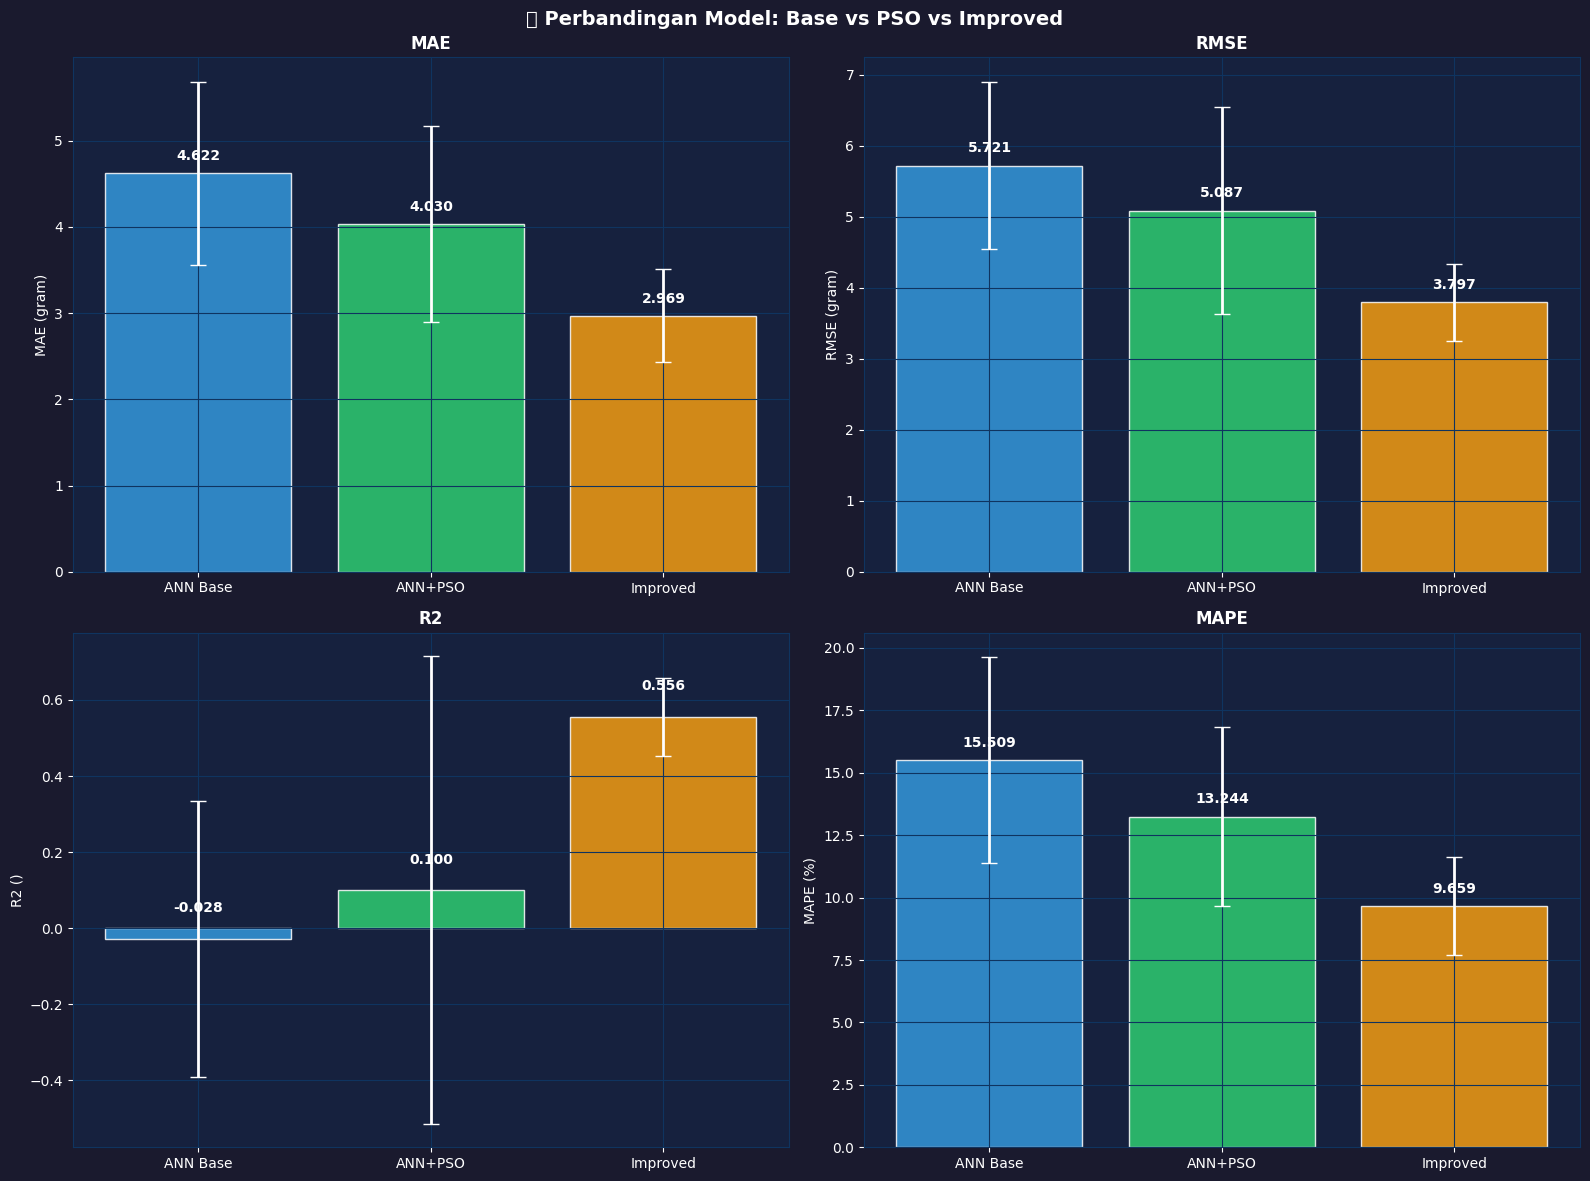

✅ Simpan → output/plots/improved_comparison.png


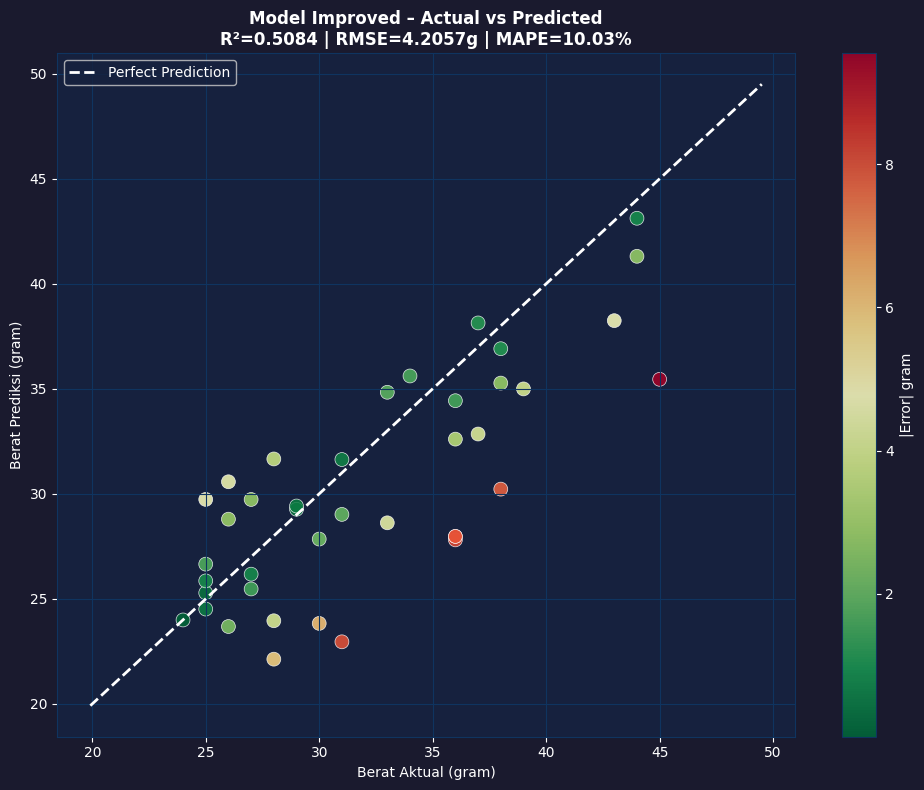


🏆 NOTEBOOK 08 – IMPROVED PIPELINE SELESAI!
  Fitur digunakan : 10 dari 17
  Target transform: y asli
  Scaler          : MinMaxScaler
  Arsitektur PSO  : (71, 44, 23)
  Learning Rate   : 0.046097
  Alpha (L2)      : 0.094409

  Test Set Performance:
    MAE  : 3.2956 gram
    RMSE : 4.2057 gram
    R²   : 0.5084
    MAPE : 10.03%


In [12]:
# Dashboard perbandingan
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 Perbandingan Model: Base vs PSO vs Improved',
             fontsize=14, fontweight='bold', color='white')

metrics_list = ['MAE', 'RMSE', 'R2', 'MAPE']
models = ['ANN Base', 'ANN+PSO', 'Improved']
colors = ['#3498DB', '#2ECC71', '#F39C12']

for ax, met in zip(axes.flatten(), metrics_list):
    means = [baseline_cv[met]['mean'], pso_baseline_cv[met]['mean'], imp_cv[met]['mean']]
    stds  = [baseline_cv[met]['std'],  pso_baseline_cv[met]['std'],  imp_cv[met]['std']]

    bars = ax.bar(models, means, color=colors, alpha=0.85, edgecolor='white')
    ax.errorbar(models, means, yerr=stds, fmt='none', color='white', capsize=6, lw=2)

    # Label nilai
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.1,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(met, fontsize=12, fontweight='bold')
    unit = 'gram' if met in ['MAE','RMSE'] else ('%' if met == 'MAPE' else '')
    ax.set_ylabel(f'{met} ({unit})')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/improved_comparison.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/improved_comparison.png')

# Actual vs Predicted – Improved
fig, ax = plt.subplots(figsize=(10, 8))
err = np.abs(y_test_orig - yp_test)
sc  = ax.scatter(y_test_orig, yp_test, c=err, cmap='RdYlGn_r', s=100,
                  alpha=0.85, edgecolors='white', lw=0.5)
plt.colorbar(sc, ax=ax, label='|Error| gram')
lim = [min(y_test_orig.min(), yp_test.min())*0.9,
       max(y_test_orig.max(), yp_test.max())*1.1]
ax.plot(lim, lim, 'w--', lw=2, label='Perfect Prediction')
ax.set_title(f'Model Improved – Actual vs Predicted\nR²={m_test["R2"]:.4f} | RMSE={m_test["RMSE"]:.4f}g | MAPE={m_test["MAPE"]:.2f}%',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Berat Aktual (gram)'); ax.set_ylabel('Berat Prediksi (gram)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/improved_actual_vs_predicted.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('\n' + '='*60)
print('🏆 NOTEBOOK 08 – IMPROVED PIPELINE SELESAI!')
print('='*60)
print(f'  Fitur digunakan : {len(SELECTED_FEATURES)} dari {len(ALL_FEATURES)}')
print(f'  Target transform: {"log(1+y)" if USE_LOG else "y asli"}')
print(f'  Scaler          : {scaler_name}')
print(f'  Arsitektur PSO  : {BEST_LAYERS}')
print(f'  Learning Rate   : {BEST_LR:.6f}')
print(f'  Alpha (L2)      : {BEST_ALPHA:.6f}')
print(f'\n  Test Set Performance:')
print(f'    MAE  : {m_test["MAE"]:.4f} gram')
print(f'    RMSE : {m_test["RMSE"]:.4f} gram')
print(f'    R²   : {m_test["R2"]:.4f}')
print(f'    MAPE : {m_test["MAPE"]:.2f}%')